## Analysing first principle results

In [1]:
import pandas as pd
import json
import os
import numpy as np; np.random.seed(42)
from glob import glob
from tqdm import tqdm
import seaborn as sns
import pdb

# !pip install textalloc
import textalloc as ta

import sys; sys.path.append('..')
from pareto_utils import front

import matplotlib.pyplot as plt
import matplotlib

matplotlib.rc('pdf', fonttype=42)
matplotlib.rc('ps', fonttype=42)

params = {'mathtext.default': 'regular' }          
plt.rcParams.update(params)

sns.set(font_scale=1.25, style='whitegrid')
sns.set(palette='magma')
sns.set_style("whitegrid")

rdir  = '../../results/first-principles-tuning/'
figdir = f'../figs/first-principles-tuning/'
ddir = '../../datasets/firstprinciples'

# This one also works with the blackbox!
# rdir  = '../../results/black-box-tuning/'
# figdir = f'../figs/black-box-tuning/'
# ddir = '../../datasets/blackbox'

def save(name='tmp',h=None):
    name = name.strip().replace(' ','-').replace('%','pct')
    if h == None:
        h = plt.gcf()

    h.tight_layout()

    print('saving',figdir+'/'+name+'.pdf')

    if not os.path.exists(figdir):
        os.makedirs(figdir)

    plt.savefig(figdir+'/'+name+'.pdf', bbox_inches='tight')
    plt.savefig(figdir+'/'+name+'.png', bbox_inches='tight')

# read data from feather

In [2]:
df_results = pd.read_feather(rdir+'results.feather')
df_sum = pd.read_csv(rdir+'results-summary.csv.gz', compression='gzip')

print('mean trial count:')
print(df_results.groupby('algorithm')['dataset'].count().sort_values()
      / df_results.dataset.nunique())

mean trial count:
algorithm
GP-GOMEA              11.615385
FEAT                  28.846154
TIR                   29.307692
EQL                   29.846154
Rils-Rols             29.923077
AFP_FE                30.000000
Bingo                 30.000000
AFP                   30.000000
Brush                 30.000000
FFX                   30.000000
GPZGD                 30.000000
Genetic Engine        30.000000
Genetic Engine 1p1    30.000000
Genetic Engine hc     30.000000
EPLEX                 30.000000
AFP_EHC               30.000000
ITEA                  30.000000
Genetic Engine rs     30.000000
Operon                30.000000
PS-Tree               30.000000
QLattice              30.000000
PYSR                  30.000000
gplearn               30.000000
Name: dataset, dtype: float64


# Pareto plot

Plot the method results as trade-offs between accuracy and simplicity

In [3]:
def bootstrap(val, n = 1000, fn=np.mean):
    val_samples = []
    for i in range(n):
        sample = np.random.randint(0,len(val)-1, size=len(val))
        val_samples.append( fn(val[sample]) )

    m = np.mean(val_samples)
    sd = np.std(val_samples)
    ci_upper  = np.quantile(val_samples,0.95)
    ci_lower  = np.quantile(val_samples,0.05)

    return m, sd, ci_upper,ci_lower

In [4]:
fs_data = {
    'first_principles_bode' : {'model_size': 6, 'r2_zero_test' : 1.0,
                               'predict': lambda X: 0.4 + 0.3 * np.exp(X[:,0]),
                               'latex_eq': r'$0.4 + 0.3 \cdot e^{x}$'},

    'first_principles_hubble' : {'model_size': 3, 'r2_zero_test' : 1.0,
                                 'predict': lambda X: 73.3 * X[:, 0],
                                 'latex_eq' : r'$D \cdot H_0$'},  # H0 * D # H0=73.3 huble constant # 'latex_eq' : r'$$'

    # ----------------------------------------------------
        # I had to divide and multiply the values in order to fix the first principle equation from miles paper
        'first_principles_kepler' : {'model_size': 8, 'r2_zero_test' : 1.0,
                                     'predict': lambda X: 1000*np.sqrt(X[:, 0]**3/7.5),
                                     'latex_eq' : r'$1000 \cdot \sqrt{\frac{k \cdot a^3}{7.5}}$'}, # mp.sqrt(k * a**3) # k=None if considered irrelevant

        # k: 26.1, k2: None
        'first_principles_tully_fisher' : {'model_size': 5, 'r2_zero_test' : 1.0,
                                           'predict': lambda X: 26.1* X[:, 0]**2.5,
                                           'latex_eq' : r'$k \cdot \Delta V^{2.5}$' }, # k * DV**2.5 + k2

        # 2 * h * nu**3 / (c**2) * (1 / (mp.exp(h * nu / (k_B * T)) - 1)), h: 6.62607004e-34, k_B: 1.38064852e-23, c: 299792458
        'first_principles_planck' : {'model_size': 20, 'r2_zero_test' : 1.0,
                                     'predict': lambda X: 2 * 6.62607004e-34 * X[:, 0]**3 / (299792458**2) * (1 / (np.exp(6.62607004e-34 * X[:, 0] / (1.38064852e-23 * X[:, 1])) - 1)),
                                     'latex_eq' : r'$\frac{2 \cdot h *\cdot nu^3}{(c^2)} \cdot \frac{1}{e^{\frac{h \cdot nu}{k_B \cdot T}} - 1}$'
                                     }, 

        'first_principles_ideal_gas' : {'model_size': 7, 'r2_zero_test' : 1.0,
                                        'predict': lambda X: X[:,0] * 8.314 * X[:,1] / X[:,2],
                                        'latex_eq' : r'$\frac{n \cdot R \cdot T}{V}$'}, # n * R * T / V

        'first_principles_leavitt' : {'model_size': 5, 'r2_zero_test' : 1.0,
                                      'predict': lambda X: X[:, 0] * -2.084 + 15.65,
                                      'latex_eq' : r'$\log_{10}{P} \cdot \alpha + \delta$'}, # mp.log10(P) * alpha + delta, but X0 is already logP

        'first_principles_newton' : {'model_size': 9, 'r2_zero_test' : 1.0,
                                     'predict':lambda X: 6.67408e-11 * X[:, 1] * X[:, 2] / X[:, 0]**2,
                                     'latex_eq' : r'$\frac{G \cdot m_1 \cdot m_2}{r^2}$'}, # G * m1 * m2 / r**2

        # 1 / (R_H * (1 / n_1**2 - 1 / n_2**2))  R_H: 1.097e7
        'first_principles_rydberg' : {'model_size': 15, 'r2_zero_test' : 1.0,
                                      'predict': lambda X: 1 / (1.097e7 * (1 / X[:, 0]**2 - 1 / X[:, 1]**2)),
                                      'latex_eq' : r'$\frac{1}{(R_H \cdot (\frac{1}{n_1^2} - \frac{1}{n_2^2}))}$'}, 

        # alpha: -1.20, phi_ast: 0.002, L_ast: 2.5e8
        'first_principles_schechter' : {'model_size': 13, 'r2_zero_test' : 1.0,
                                        'predict': lambda X: (0.002/2.5e8) * (X[:, 0] / 2.5e8)**-1.20 * np.exp(-X[:, 0] / 2.5e8),
                                        'latex_eq' : r'$\frac{phi_{ast}}{L_{ast}} \cdot \frac{L}{L_{ast}}^\alpha \cdot e^{\frac{-L}{L_{ast}}}$'}, # (phi_ast/L_ast) * (L / L_ast)**alpha * mp.exp(-L / L_ast)

        'first_principles_absorption' : {'model_size': 2, 'r2_zero_test' : 0.987,
                                         'predict': lambda X: np.log(X[:, 0]),
                                         'latex_eq' : r'$\log{x}$'},

        'first_principles_supernovae_zr' : {'model_size': 14, 'r2_zero_test' : 0.987,
                                            'latex_eq' : r'$\frac{A}{B \cdot e^{(C\cdot t)} + e^{(-D\cdot t)}}$'}, # A / B * e^(C*t) + e^(-D*t)

        'first_principles_supernovae_zg' : {'model_size': 1, 'r2_zero_test' :0.987, 
                                            'latex_eq' : r'$\frac{A}{B \cdot e^{(C\cdot t)} + e^{(-D\cdot t)}}$'}, # A / B * e^(C*t) + e^(-D*t)

}

In [5]:
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import sys; sys.path.append('../../experiment/')
from read_file import read_file

# Updating r2 based on the available data
for ds, attr in fs_data.items():
    if not 'predict' in attr:
        continue
    print("----------------------")
    # load the dataset
    features, labels, feature_names = read_file(f"{ddir}/{ds}/{ds}.tsv.gz", use_dataframe=False)
    print(feature_names)
    print(features.shape)

    y_pred = attr['predict'](features)

    # Miles generated data have log(y) instead of raw y in the labels column
    if ds in ['first_principles_bode', 'first_principles_ideal_gas', 'first_principles_newton', 'first_principles_planck',
              'first_principles_rydberg', 'first_principles_schechter']:
        y_pred = np.log(y_pred)
    
    if ds == 'first_principles_planck':
        idxs = y_pred != -np.inf
        y_pred = y_pred[idxs]
        labels = labels[idxs]
        # print(y_pred)

    print(features[:3])
    print(y_pred[:10])
    print(labels[:10])

    # evaluate r2
    score = r2_score(labels, y_pred)
    
    print(ds, score)
    fs_data[ds]['r2_zero_test'] = np.maximum(0.0, score)

----------------------
compression: gzip
filename: ../../datasets/firstprinciples/first_principles_bode/first_principles_bode.tsv.gz
['n']
(8, 1)
[[-1000]
 [    1]
 [    2]]
[-0.91629073  0.1951428   0.96192041  1.86029952  2.82015463  3.80497101
  4.79932675  5.7972423 ]
[ 0.39  0.72  1.    1.52  2.77  5.2   9.58 19.22]
first_principles_bode 0.3000946845820114
----------------------
compression: gzip
filename: ../../datasets/firstprinciples/first_principles_hubble/first_principles_hubble.tsv.gz
['D']
(32, 1)
[[0.03235072]
 [0.03698888]
 [0.03268063]]
[ 2.37130742  2.71128491  2.39548992 15.36299948 18.92067185 19.88085932
 20.19096431 19.85383182 49.47170331 66.34113024]
[ -17.67936502   30.54590619   56.88059151   38.56081042    7.64617982
  -31.88495798  -75.76316249 -115.21667411  203.18655514  215.33505405]
first_principles_hubble -0.9341296072236938
----------------------
compression: gzip
filename: ../../datasets/firstprinciples/first_principles_kepler/first_principles_kepler.ts

/home/ch246537/srbench_2024/postprocessing/notebooks/../../experiment/read_file.py:14: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support sep=None with delim_whitespace=False; you can avoid this warning by specifying engine='python'.
  input_data = pd.read_csv(filename, sep=sep, compression=compression)
/home/ch246537/srbench_2024/postprocessing/notebooks/../../experiment/read_file.py:14: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support sep=None with delim_whitespace=False; you can avoid this warning by specifying engine='python'.
  input_data = pd.read_csv(filename, sep=sep, compression=compression)
/home/ch246537/srbench_2024/postprocessing/notebooks/../../experiment/read_file.py:14: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support sep=None with delim_whitespace=False; you can avoid this warning by specifying engine='python'.
  input_data = pd.read_csv(filename,

(5523, 22)
(261, 22)


,dataset,algorithm,random_state,training time (s),symbolic_model,mse_test,mae_test,r2_test,model_size,params_str,...,pre_trained,gp_alg,r2_zero_test,friedman_dataset,algorithm_count,mse_test_rank_per_trial,mae_test_rank_per_trial,r2_test_rank_per_trial,model_size_rank_per_trial,r2_zero_test_rank_per_trial
4,first_principles_absorption,AFP,15795,145.608408,((cos(x_0)-0.349)+(sin(x_0)+x_0)),0.001169,0.031652,0.997807,7,"{'AR': False, 'AR_lookahead': False, 'AR_na': ...",...,False,True,0.997807,False,22,1.5,2.0,1.5,9.0,1.5
37,first_principles_absorption,AFP_EHC,1685,82.071811,(0.946*(x_0-log((x_0-0.522)))),0.013047,0.110057,0.954449,10,"{'AR': False, 'AR_lookahead': False, 'AR_na': ...",...,False,False,0.954449,False,22,13.0,13.0,13.0,8.5,13.0
72,first_principles_absorption,AFP_FE,23654,142.848228,(sin((0.28+x_0))+(0.656*x_0)),0.005657,0.057399,0.996751,8,"{'AR': False, 'AR_lookahead': False, 'AR_na': ...",...,False,True,0.996751,False,22,2.0,2.0,1.5,8.5,1.5
93,first_principles_absorption,Bingo,14423,333.941939,-681064.1056912638 + (0.9888265754361456)*(688...,0.000474,0.019271,0.998276,31,"{'clo_alg': 'lm', 'clo_threshold': 1e-05, 'cro...",...,False,False,0.998276,False,22,4.0,7.0,7.0,16.5,7.0
145,first_principles_absorption,Brush,5390,89.366631,"1.99*Tanh(0.57*Add(1.49*Xaxis0,0.23))",0.000696,0.021529,0.999502,8,"{'pop_size': 250, 'max_gens': 250, 'max_stall'...",...,False,False,0.999502,False,22,1.0,1.0,1.0,9.5,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8563,first_principles_tully_fisher,PS-Tree,21962,253.936524,"Add(Mul(Integer(-1), Float('0.7333505799152924...",0.130630,0.353752,0.941555,15,"{'height_limit': 6, 'n_pop': 25, 'n_gen': 500,...",...,False,True,0.941555,False,22,3.0,6.0,3.0,12.0,3.0
8589,first_principles_tully_fisher,PYSR,16023,3173.620667,0.5216491*DV*sin(11.8681543002477*DV) - DV - 0...,0.102480,0.268713,0.948047,12,"{'adaptive_parsimony_scaling': 1000.0, 'alpha'...",...,False,False,0.948047,False,22,1.0,1.0,1.0,11.0,1.0
8620,first_principles_tully_fisher,QLattice,16850,3643.557426,2.05267 - 2.26915*sqrt(0.743224*DV + 1),0.048190,0.196120,0.980446,11,"{'criterion': 'wide_parsimony', 'function_name...",...,True,False,0.980446,False,22,1.0,1.0,1.0,11.0,1.0
8653,first_principles_tully_fisher,Rils-Rols,21962,247.465496,-2.178415*DV + 2.223824*sqrt(exp(DV)) - 0.8925...,0.125782,0.309436,0.943724,49,"{'complexity_penalty': 0.001, 'max_complexity'...",...,False,False,0.943724,False,22,2.0,2.5,2.0,19.0,2.0


Index(['dataset', 'algorithm', 'random_state', 'training time (s)',
       'symbolic_model', 'mse_test', 'mae_test', 'r2_test', 'model_size',
       'params_str', 'training time (hr)', 'symbolic_alg', 'pre_trained',
       'gp_alg', 'r2_zero_test', 'friedman_dataset', 'algorithm_count',
       'mse_test_rank_per_trial', 'mae_test_rank_per_trial',
       'r2_test_rank_per_trial', 'model_size_rank_per_trial',
       'r2_zero_test_rank_per_trial'],
      dtype='object')


/tmp/ipykernel_255336/1590844264.py:16: FutureWarning: The default value of numeric_only in DataFrameGroupBy.median is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  pareto_data = df_sum.groupby(['algorithm', facet_column]).agg(estimator)
/tmp/ipykernel_255336/1590844264.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if x_greater_is_better: objs.loc[:, xcol] = -objs.loc[:, xcol]
/tmp/ipykernel_255336/1590844264.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/

Writing equation to plot


...

Writing equation to plot


/tmp/ipykernel_255336/1590844264.py:55: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  ax = sns.scatterplot(


Writing equation to plot


/tmp/ipykernel_255336/1590844264.py:55: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  ax = sns.scatterplot(


Writing equation to plot
saving ../figs/first-principles-tuning//pareto_facets_r2_zero_test_model_size.pdf


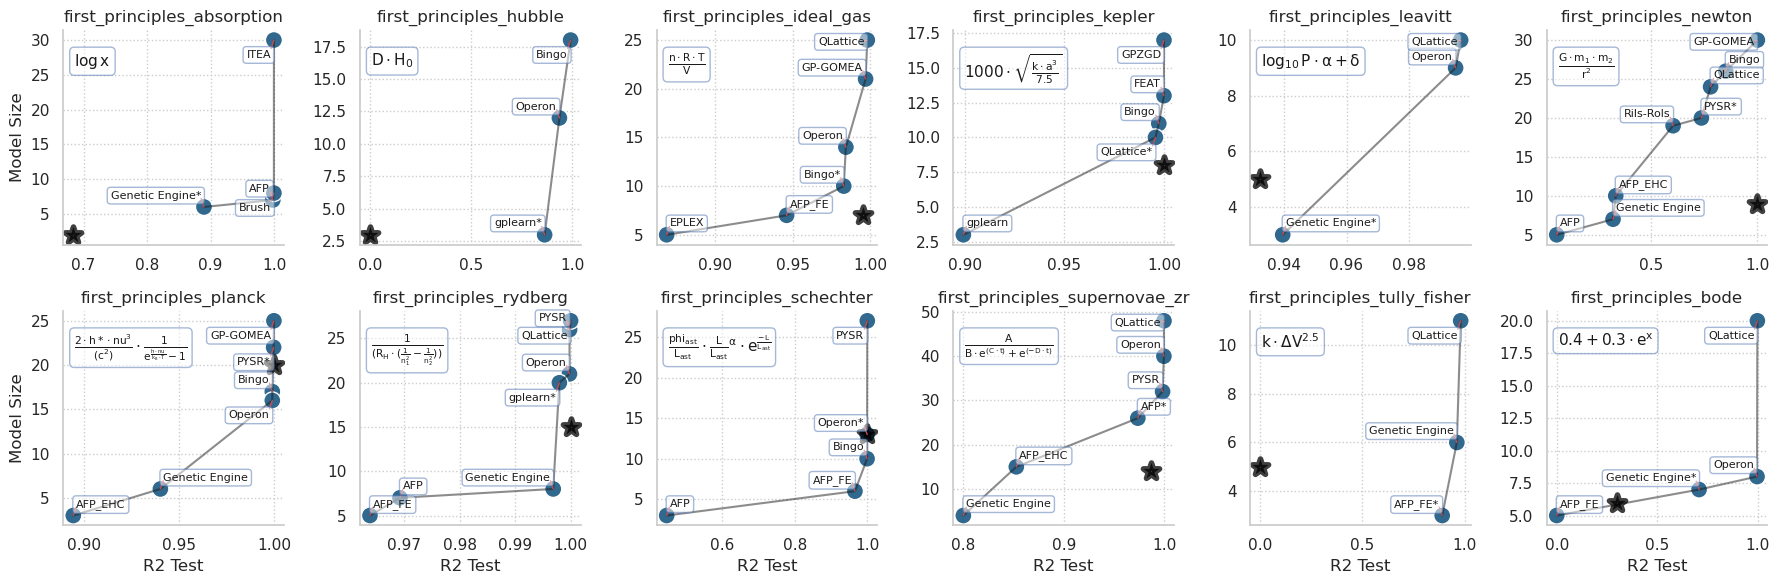

In [6]:
def create_pareto_facets(df_sum, estimator=np.median, plot_error=True, plot_dominated=False,
    levels = 1, # number of different colors for the pareto plots
    levels_to_show = 1, # Change here to include or exclude algorithms
    facet_column='dataset', xcol = 'r2_test_rank', ycol = 'model_size_rank'):

    # This could be better but works for most cases. multiply by -1 if
    # greater is better, so the pareto front uses the inverse. The front()
    # method expects minimization problems
    check = lambda s: False if ('rank' in s) or ('size' in s) or ('mse' in s) else True

    x_greater_is_better = check(xcol)
    y_greater_is_better = check(ycol)
    # print(x_greater_is_better, y_greater_is_better)

    # Median across datasets
    pareto_data = df_sum.groupby(['algorithm', facet_column]).agg(estimator)
    data = pareto_data[[xcol,ycol]].reset_index()
    
    pareto_ranks = np.ones(len(data)) * levels
    for val in data[facet_column].unique():
        # print(val)
        objs = data[data[facet_column]==val] # Aux. copy for finding the PFs
        if x_greater_is_better: objs.loc[:, xcol] = -objs.loc[:, xcol]
        if y_greater_is_better: objs.loc[:, ycol] = -objs.loc[:, ycol]

        for el in range(levels):
            if np.all(np.isfinite(objs[[xcol, ycol]])==False):
                break
            PF = front(objs.loc[:,xcol].values,
                       objs.loc[:,ycol].values)
            # print(PF)
            if len(PF)>0:
                pareto_ranks[objs.iloc[PF].index] = el

            objs.iloc[PF,:] = np.inf

    data.loc[:,'pareto_rank'] = pareto_ranks

    # Initialize FacetGrid
    g = sns.FacetGrid(
        data,
        col=facet_column,
        height=3,
        aspect=1,
        col_wrap=6,
        margin_titles=True,
        sharex=False,
        sharey=False,
    )
    
    cmap = sns.color_palette("viridis", n_colors=levels+1)

    pareto_optimal_solutions = []
    def custom_plot(data, **kwargs):
        ax = sns.scatterplot(
            data=data if plot_dominated else data[data['pareto_rank']<levels_to_show],
            x=xcol,
            y=ycol,
            hue='pareto_rank',
            s=150,
            palette=cmap,
            legend=False
        )
        
        styles=['-','-.','--',':', ':', ':', ':', ':']
        for el in range(levels):
            pfset = data[data['pareto_rank']==el].sort_values(by=[xcol, ycol])
            ax.plot(pfset[xcol], pfset[ycol], styles[el]+'k', alpha=0.5, zorder=1)

        ds_name = data['dataset'].values[0] # data is already filtered by column name
        
        # Setting the axis limits to the pareto fronts with annotations
        # ax.set_xlim(min(data[data['pareto_rank']<levels_to_show][xcol].min(), fs_data[ds_name][xcol])*0.95 - 0.05, 
        #             1.05)
                    
        # ax.set_ylim(min(data[data['pareto_rank']<levels_to_show][ycol].min(), fs_data[ds_name][ycol])*0.9,
        #             max(data[data['pareto_rank']<levels_to_show][ycol].max(), fs_data[ds_name][ycol])*1.15)
            
        # Add confidence intervals by bootstrapping the 30 runs
        if plot_error:
            for alg, dg in data.groupby('algorithm'):
                # print(alg)
                # display(dg)
                # Getting the individual scores
                dg_rs = df_sum[ (df_sum['algorithm']==dg['algorithm'].values[0]) 
                            & (df_sum['dataset']==dg['dataset'].values[0])]
                
                # display(dg_rs)
                
                assert len(dg)==1

                if (len(dg_rs) <= 1) or (not np.isfinite(dg['pareto_rank'].values[0])):
                    continue

                _, sdx, ciux, cilx = bootstrap(dg_rs[xcol].values, fn=estimator, n=1000)
                _, sdy, ciuy, cily = bootstrap(dg_rs[ycol].values, fn=estimator, n=1000)
                
                # print("CI calculated for", alg)
                # print(xcol, ciux, cilx)
                # print(ycol, ciuy, cily)

                # display(data)
                plt.plot(
                        [cilx,ciux],
                        [dg[ycol], dg[ycol]],
                        alpha=0.5,
                        linewidth=2,
                        color=cmap[int(dg['pareto_rank'].values[0])],
                        zorder=-999
                        )
                plt.plot(
                        [dg[xcol], dg[xcol]],
                        [cily,ciuy],
                        alpha=0.5,
                        linewidth=2,
                        color=cmap[int(dg['pareto_rank'].values[0])],
                        zorder=-999
                        )

        # Plotting the heuristic
        if (xcol in ['model_size', 'r2_zero_test']) and (ycol in ['model_size', 'r2_zero_test']):
            if ds_name in fs_data:
                plt.scatter(fs_data[ds_name][xcol], fs_data[ds_name][ycol], 
                    marker='*', 
                    color='black', 
                    s=150, 
                    linewidth=4,
                    alpha=0.75,
                    linestyle='None',
                    zorder=2)
                
                if 'latex_eq' in fs_data[ds_name]:
                    print("Writing equation to plot")
                    plt.text(.05, .9, fs_data[ds_name]['latex_eq'], color="k", fontsize=11,
                        horizontalalignment="left", verticalalignment="top", transform = ax.transAxes,
                        **{"bbox":dict(facecolor='w', edgecolor='b', boxstyle='round', alpha=0.5)})

        # # Add labels
        ta_x, ta_y, ta_text = [], [], []
        xoff, yoff = 0.0, -0.03 #.5, 0.3
        for idx, row in data.iterrows():
            if row['pareto_rank'] < levels_to_show: # Naming only good ones
                # ax.text(s=row['algorithm'], x=row[xcol]-xoff, y=row[ycol]-yoff,
                #         # ha='right' if x_greater_is_better else 'left',
                #         ha='center',
                #         va='bottom',
                #         rotation=-20,
                #         fontsize=8,
                #         zorder=1000-row['pareto_rank']*100,
                #         bbox=dict(facecolor='w', edgecolor='b', boxstyle='round', alpha=0.5)
                #         )

                ta_text.append(row['algorithm'])
                ta_x.append(row[xcol])
                ta_y.append(row[ycol])
        
        # printing the equation closest to the first principles --- it works but it is terrible to read
        if row['dataset'] in fs_data:
            norm_target_x = (fs_data[row['dataset']][xcol] - min(ta_x)) / (max(ta_x) - min(ta_x))
            norm_target_y = (fs_data[row['dataset']][ycol] - min(ta_y)) / (max(ta_y) - min(ta_y))

            x_min, x_max = min(ta_x), max(ta_x)
            normalized_x = [(xi - x_min) / (x_max - x_min) if x_max != x_min else 0 
                            for xi in ta_x]
            y_min, y_max = min(ta_y), max(ta_y)
            normalized_y = [(yi - y_min) / (y_max - y_min) if y_max != y_min else 0 
                            for yi in ta_y]

            distances = np.sqrt(
                np.square(np.array(normalized_x) - norm_target_x) +
                np.square(np.array(normalized_y) - norm_target_y)
            )
            closest_idx = np.argmin(distances)
            if ds_name == 'first_principles_bode': # Picking the second one
                closest_idx = np.argsort(distances)[1]
                
            symbolic_model = str(df_sum[ (df_sum['algorithm']==ta_text[closest_idx]) 
                                       & (df_sum['dataset']==ds_name) ]['symbolic_model'].values[-1])
            pareto_optimal_solutions.append({
                'algorithm': ta_text[closest_idx],
                'dataset': ds_name,
                xcol: ta_x[closest_idx],
                ycol: ta_y[closest_idx],
                'symbolic_model': symbolic_model
            })
            if False: # add the model to the text
                ta_text[closest_idx] = ta_text[closest_idx] + '\n' + symbolic_model
            if True: # Add simple marker to show which one was closest
               ta_text[closest_idx] = ta_text[closest_idx] + '*'

        ta.allocate(ax, ta_x, ta_y, ta_text,
                    x_scatter=data[data['pareto_rank']<levels_to_show][xcol].values + \
                            ([fs_data[row['dataset']][xcol]] if row['dataset'] in fs_data else []),
                    y_scatter=data[data['pareto_rank']<levels_to_show][ycol].values + \
                            ([fs_data[row['dataset']][ycol]] if row['dataset'] in fs_data else []),
                    textsize=8, rotation=0, **{"bbox":dict(facecolor='w', edgecolor='b', boxstyle='round', alpha=0.5)})


        # ax.set_aspect(1.0)
        ax.grid(ls=":")
        # ax.set_xlim(-1, 1)
        # ax.set_yscale("log")
        # sns.despine(left=True, bottom=True)
        
        return ax
    
    g.map_dataframe(custom_plot, col=facet_column)
    g.set_titles(
        col_template="{col_name}",
        row_template='{row_name}')
    

    for i, (title, ax) in enumerate(g.axes_dict.items()):
        if i%6==0:  # Leftmost plots
            ax.set_ylabel(ycol.replace('_', ' ').title())
        else:
            ax.set_ylabel('')

        if i>=6:  # Bottom row plots
            ax.set_xlabel(xcol.replace('_', ' ').replace('zero ', '').title())
        else:  # Remove labels for inner plots
            ax.set_xlabel('')

    plt.tight_layout()
    save(name="pareto_facets_"+xcol+'_'+ycol)
    return g, pareto_optimal_solutions

# Dropping some methods
df_results_plot = df_results.copy()
df_results_plot = df_results_plot[~df_results_plot['algorithm'].isin(['Genetic Engine rs', 'Genetic Engine hc', 'Genetic Engine 1p1'])]

df_results_plot = df_results_plot[~df_results_plot['dataset'].isin(['first_principles_supernovae_zg'])]

# Only valid model sizes
df_results_plot = df_results_plot[df_results_plot['model_size']>1]

# Selecting as final result the best performing r2
idx = df_results_plot.groupby(['algorithm', 'dataset'])['r2_zero_test'].transform(max) == df_results_plot['r2_zero_test']
print(df_results_plot.shape)
df_results_plot = df_results_plot[idx]
print(df_results_plot.shape)
display(df_results_plot)
print(df_results_plot.columns)

g, pareto_optimal_solutions = create_pareto_facets(df_results_plot, plot_error=False, 
    levels = 1, # number of different colors for the pareto plots
    levels_to_show = 1, 
    xcol='r2_zero_test', ycol='model_size')

In [7]:
pareto_optimal_solutions_df = pd.DataFrame(pareto_optimal_solutions)
with pd.option_context("max_colwidth", 1000):
    print(pareto_optimal_solutions_df.replace({'first_principles_':''}, regex=True).sort_values('dataset').round(2).to_latex(index=False))

\begin{tabular}{llrrl}
\toprule
     algorithm &       dataset &  r2\_zero\_test &  model\_size &                                                                                                                                                      symbolic\_model \\
\midrule
Genetic Engine &    absorption &          0.89 &         6.0 &                                                                                                                                              (sin(x0) + (x0 / 2.0)) \\
Genetic Engine &          bode &          0.71 &         7.0 &                                                                                                                                           ((2.0 ** x0) - (e / 2.0)) \\
       gplearn &        hubble &          0.86 &         3.0 &                                                                                                                                                       Add(0.090, D) \\
         Bingo &     ideal\_gas &  

/tmp/ipykernel_255336/1128734961.py:3: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(pareto_optimal_solutions_df.replace({'first_principles_':''}, regex=True).sort_values('dataset').round(2).to_latex(index=False))
